In [3]:
# Importamos las librerías
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import yfinance as yf

from datetime import date, datetime, time, timezone

In [4]:
# Definimos una función para obtener datos de acciones de yahoo finance
def get_stock_data(ticker, start_date, end_date):
    # Descargar los datos del ticker de inicio y fin
    data = yf.download(tickers=[ticker], start= start_date, end=end_date, multi_level_index=False)
    # Insertar una columan 'ticker', al inicio del Dataframe con el nombre del ticker.
    data.insert(0, "Ticker", ticker)

    return data

    

In [5]:
# Definir el símbolo de la acción (ticker) para Disney
ticker = 'DIS'
# La fecha de inicio para la descarga de datos:
start = datetime (2020, 1, 1)
# La fecha de fin como la fecha actual
end = datetime.today()

In [6]:
# Obtenemos los datos de las acciones de Disney
d = get_stock_data(ticker,start,end)
d.head()

[*********************100%***********************]  1 of 1 completed


,Ticker,Close,High,Low,Open,Volume
Date,,,,,,
2020-01-02,DIS,144.790268,144.790268,141.761601,141.947217,9502100
2020-01-03,DIS,143.129379,144.497163,142.689736,143.031674,7320200
2020-01-06,DIS,142.298935,142.670197,140.989769,142.191465,8262500
2020-01-07,DIS,142.347778,143.490858,142.074222,142.631114,6906500
2020-01-08,DIS,142.054672,142.767887,141.488030,142.142613,6984200


In [7]:
# Debido a que el analisis se basa solo en el precio de cierre por cada accion.
# Date como indice, ticker como columna 
d = d.reset_index().pivot(index="Date", columns="Ticker", values="Close")
d.head()

Ticker,DIS
Date,
2020-01-02,144.790268
2020-01-03,143.129379
2020-01-06,142.298935
2020-01-07,142.347778
2020-01-08,142.054672


In [8]:
# Obtener los datos de acciones vara varios ETFs (SPY, IYW, VT, DBA, TLT, PDBC, IAU)
SPY = get_stock_data('SPY', start, end)
IYW = get_stock_data("IYW", start, end)
VT = get_stock_data("VT", start, end)
DBA = get_stock_data("DBA", start, end)
TLT = get_stock_data("TLT", start, end)
PDBC = get_stock_data("PDBC", start, end)
IAU = get_stock_data("IAU", start, end)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [9]:
# Mostramos uns resumen informativo del Dataframe 'SPY'.
SPY.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1623 entries, 2020-01-02 to 2026-06-17
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Ticker  1623 non-null   str    
 1   Close   1623 non-null   float64
 2   High    1623 non-null   float64
 3   Low     1623 non-null   float64
 4   Open    1623 non-null   float64
 5   Volume  1623 non-null   int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 88.8 KB


In [10]:
# Reestrucutrar cada Dataframe de ETF individualmente
# Esto transforma cada Dataframe para que 'Date' sea el indice,
# 'Ticker' la columna y 'Close' los valores.
SPY = SPY.reset_index().pivot(index="Date", columns="Ticker", values="Close")
IYW = IYW.reset_index().pivot(index="Date", columns="Ticker", values="Close")
VT = VT.reset_index().pivot(index="Date", columns="Ticker", values="Close")
DBA = DBA.reset_index().pivot(index="Date", columns="Ticker", values="Close")
TLT = TLT.reset_index().pivot(index="Date", columns="Ticker", values="Close")
PDBC = PDBC.reset_index().pivot(index="Date", columns="Ticker", values="Close")
IAU = IAU.reset_index().pivot(index="Date", columns="Ticker", values="Close")

In [11]:
# Concatenar todos los DF reestrucutrados de ETFs en un único DF llamado 'stock'.
# 'axis=1' indica que la concatenación es por columnas.
# 'join='outer'' asegura que todas las fechas estén presentes.
# rellenamos con NaN si algún activo no tiene datos para una fecha concreta.
stock = pd.concat([SPY, IYW, VT, DBA, TLT, PDBC, IAU], axis=1, join='outer')
stock.head()

Ticker,SPY,IYW,VT,DBA,TLT,PDBC,IAU
Date,,,,,,,
2020-01-02,296.888092,57.811771,72.245491,14.560221,113.300842,8.430120,29.219999
2020-01-03,294.640076,57.234673,71.592010,14.392557,115.045715,8.501049,29.620001
2020-01-06,295.764191,57.587753,71.856941,14.427855,114.392433,8.511180,29.920000
2020-01-07,294.932526,57.609653,71.636169,14.463151,113.830086,8.495982,30.040001
2020-01-08,296.504425,58.184319,71.927567,14.392557,113.077568,8.379459,29.820000


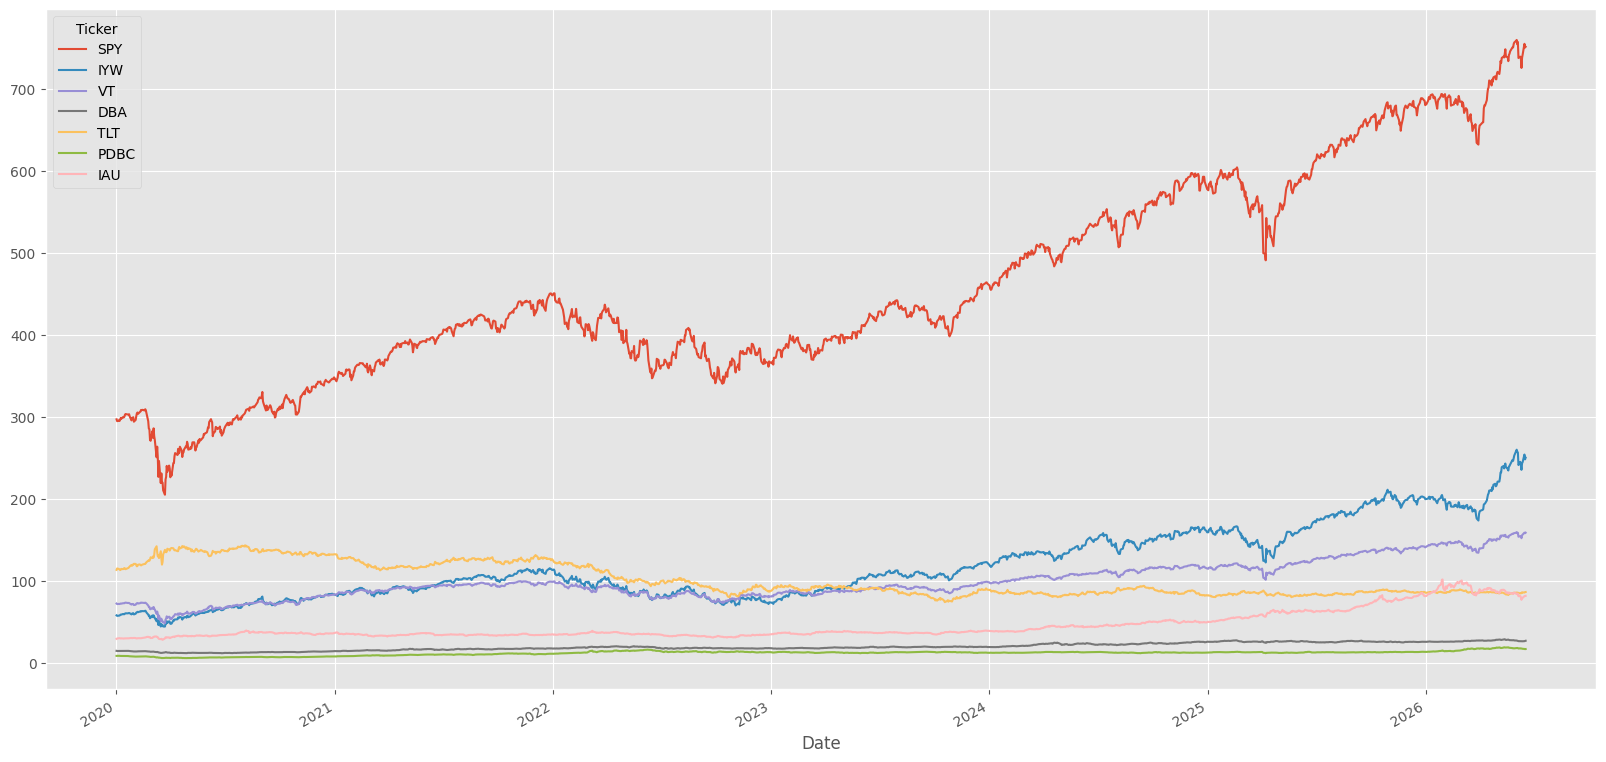

In [12]:
# Establecer el estilo de las gráficas a 'ggplot' para una apariencia estética específica
plt.style.use('ggplot')
# Graficar los precios de cierre de todos los activos en el DF 'stock'
# 'figsize' definir el tamaño de la figura(ancho,alto)
stock.plot(figsize=(20, 10))
plt.show()

# Esta gráfica muestra la evolución de los precios de cierre de varios activos financieros
# (SPY, IYW, ...) a lo largo del tiempo
# Podemo observar tendencias generales, picos y caídas. Por lo que podemos afirmar
# que hay una volatilidad vigente del activo durante todo el rango de tiempo analizado.


In [13]:
# Filtrar el DF 'stock' en la época covid.
covid = stock['2020-2-1':'2020-7-31']
covid.head()

Ticker,SPY,IYW,VT,DBA,TLT,PDBC,IAU
Date,,,,,,,
2020-02-03,296.202728,59.835255,70.797211,13.783676,120.554672,7.543540,30.120001
2020-02-04,300.717285,61.211040,71.962891,13.810148,118.931221,7.553672,29.719999
2020-02-05,304.189972,61.481323,72.616379,13.818973,117.630737,7.660062,29.760000
2020-02-06,305.213501,62.148502,72.845970,13.916041,118.160873,7.695525,29.940001
2020-02-07,303.586914,61.680988,72.254318,13.977812,119.635254,7.660062,30.000000


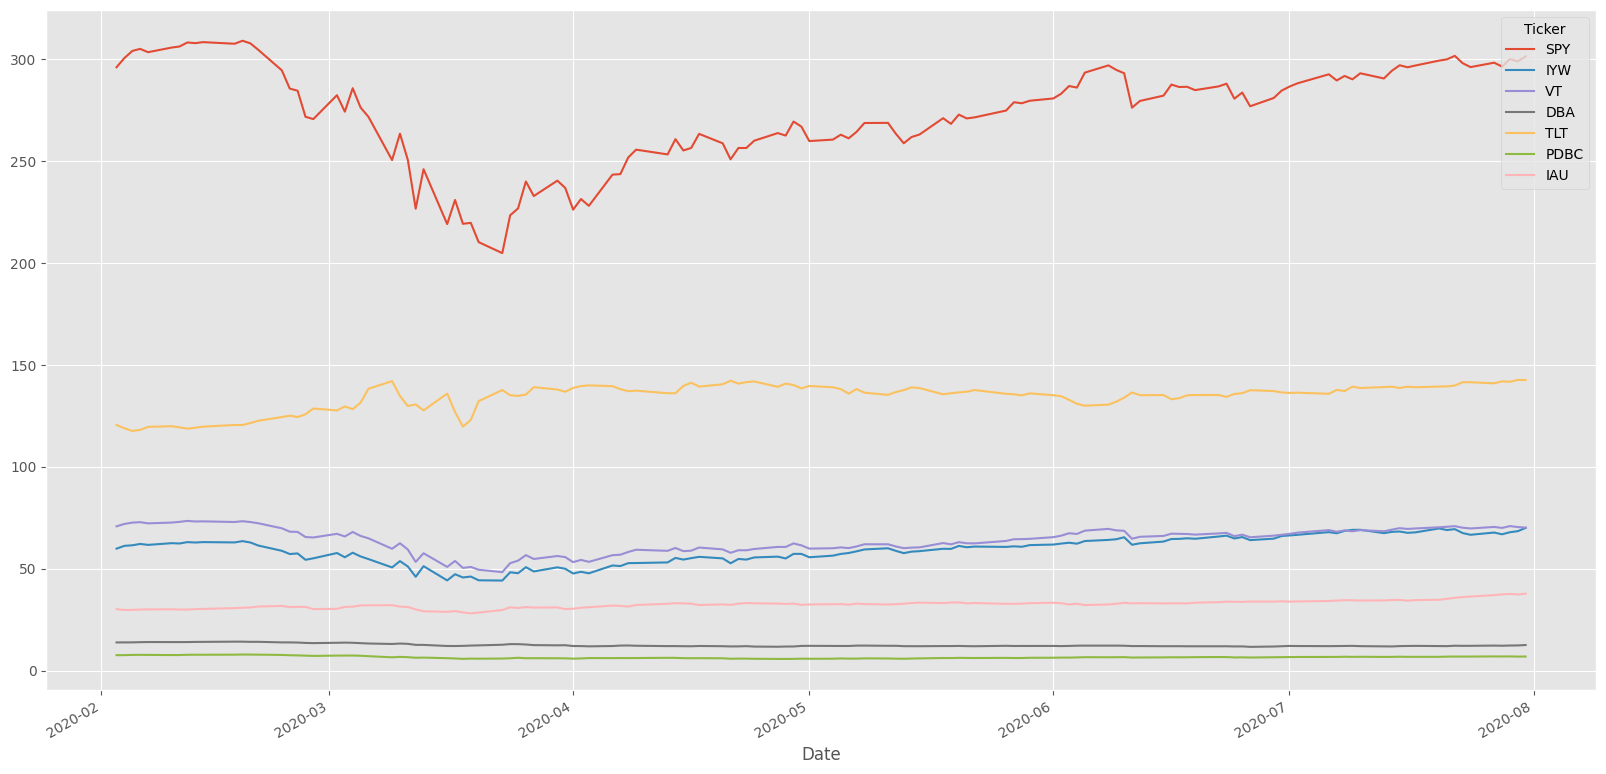

In [14]:
plt.style.use('ggplot')
# Graficar los precios de cierre de todos los activos en el DF 'covid'
covid.plot(figsize = (20, 10))
plt.show()
# Esta gráfica se enfoca en el rendimiento de los mismos activos pero durante 
# el periodo de la pandemia COVID-19.
# Es particularmente interesante observar cómo la mayoría de los activos experimentaron
# una caída brutal al inicio de la pandemia, seguida de una recuperación global, 


In [15]:
# Extraer el índice de fechas del DF 'covid' para usarlo como eje x en las gráficas.
x = covid.index

# Crear series de Pandas para los precios de cierre de 'SPY', 'IAU', 'DBA' y 'TLT' del
# DF 'covid'
s_y = covid['SPY']
i_y = covid["IAU"]
d_y = covid["DBA"]
t_y = covid["TLT"]


Text(0.5, 0.98, 'Covid 19')

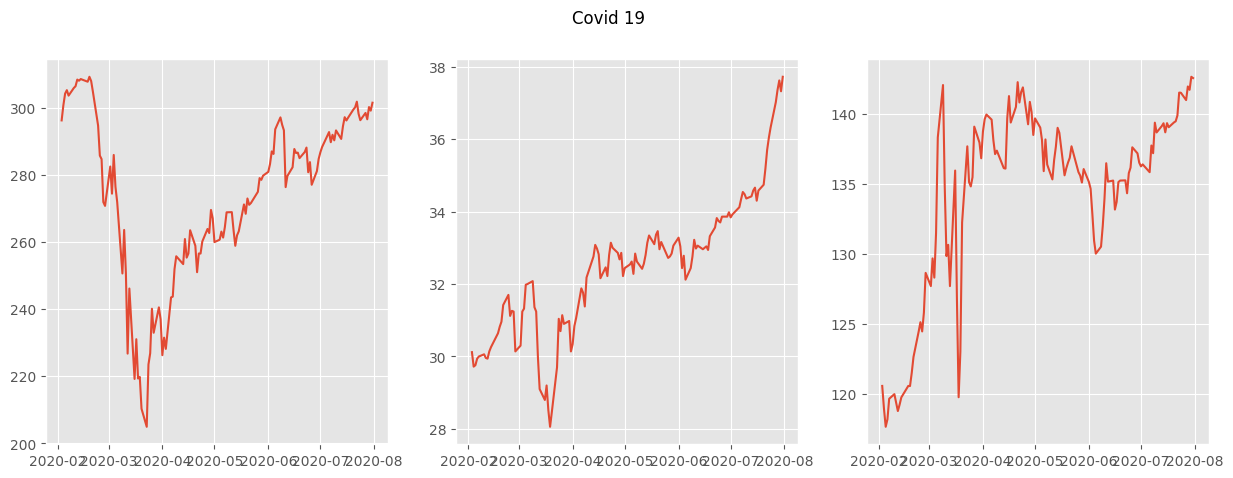

In [16]:
# Crear una figura con una cuadrícula de subplots de 1 fila y 3 columnas.
# y definimos su tamaño.
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
# Graficamos los precios del 'SPY' en el primer subplot
axs[0].plot(x, s_y)
# Graficamos los precios del 'IAU' en el primer subplot
axs[1].plot(x, i_y)
# Graficamos los precios del 'TLT' en el primer subplot
axs[2].plot(x, t_y)

fig.suptitle('Covid 19')

In [17]:
# Definnir el símbolo de la acción (ticker) como 'PDBC'.
ticker = 'PDBC'
# Establecer la fecha de inicio para la descarga de datos 
start = datetime(2020, 1, 1)
# Establecemos el final
end = datetime.today()


In [18]:
# Obtener los datos de las acciones para el ticker 'PDBC' 
df = get_stock_data(ticker, start, end)
df.head()


[*********************100%***********************]  1 of 1 completed


,Ticker,Close,High,Low,Open,Volume
Date,,,,,,
2020-01-02,PDBC,8.430120,8.445319,8.369327,8.394657,4004600
2020-01-03,PDBC,8.501048,8.531445,8.465584,8.516246,760200
2020-01-06,PDBC,8.511179,8.566907,8.495981,8.561841,1608700
2020-01-07,PDBC,8.495982,8.511180,8.469131,8.485850,1723200
2020-01-08,PDBC,8.379460,8.495982,8.289789,8.495982,923300


In [19]:
# Eliminamos las columnas: 'ticker', 'close', 'high', 'low, 'Open'
df.drop(['Ticker', 'High', 'Low', 'Open', 'Close'], axis=1, inplace=True)

In [20]:
# Mostramos las 5 primeras filas del DF despues de la eliminación.
df.head()

,Volume
Date,
2020-01-02,4004600
2020-01-03,760200
2020-01-06,1608700
2020-01-07,1723200
2020-01-08,923300


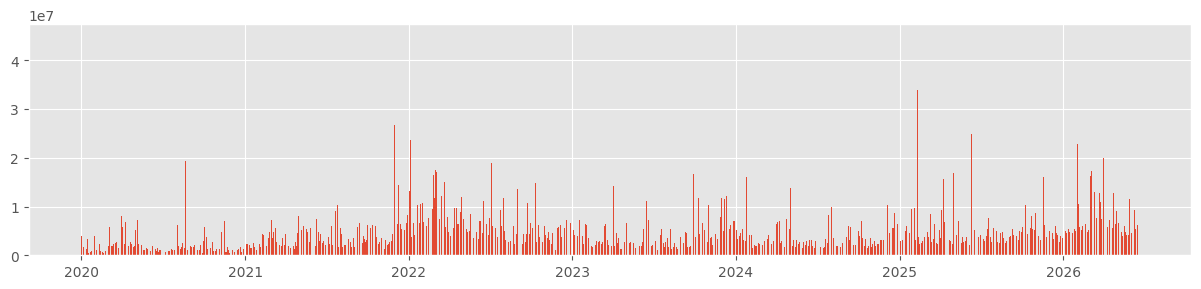

In [21]:
# Asiganar el índice del DF (date) a la variable 'x'
x = df.index
# Asignar la columna 'Volume' a la variable 'y'
y = df['Volume']

# Crear un nuevo plano para la gráfica con un tamaño específico
plt.figure(figsize=(15,3))
# Crear un gráfico de barras con las fechas en el eje x y el volumen en el eje y.
plt.bar(x, y)
# Mostramos el gráfico
plt.show()

# Esta gráfica de barras representa el volumen de negociación del ETF PDBC a lo largo
# del tiempo


In [22]:
# Obtener nuevamente los datos de las acciones para 'PDBC'
ticker = 'PDBC'
# Establecemos la fecha de inicio
start = datetime(2020,1,1)
# Establecemos fecha de fin
end = datetime.today()
df = get_stock_data(ticker, start, end)


[*********************100%***********************]  1 of 1 completed


In [23]:
df.head()

,Ticker,Close,High,Low,Open,Volume
Date,,,,,,
2020-01-02,PDBC,8.430121,8.445320,8.369328,8.394658,4004600
2020-01-03,PDBC,8.501047,8.531444,8.465583,8.516245,760200
2020-01-06,PDBC,8.511180,8.566908,8.495982,8.561842,1608700
2020-01-07,PDBC,8.495982,8.511180,8.469131,8.485850,1723200
2020-01-08,PDBC,8.379459,8.495981,8.289788,8.495981,923300


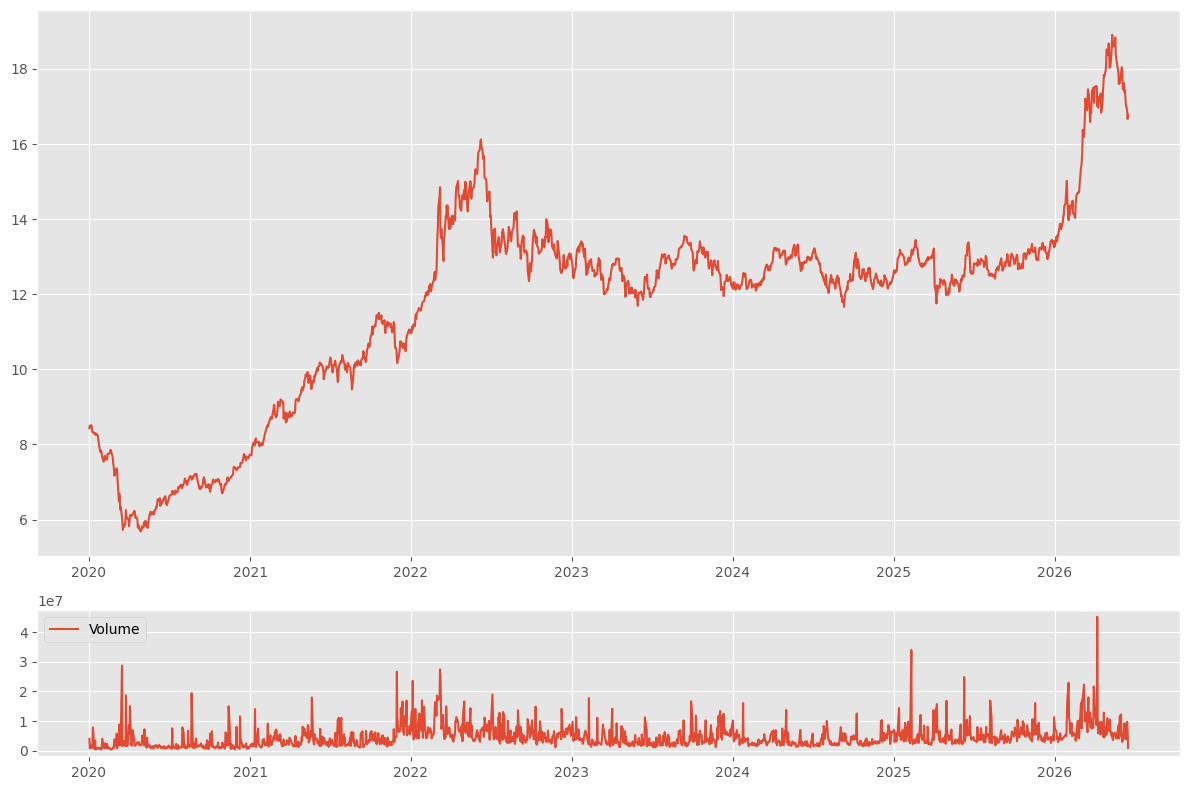

In [24]:
# Creamos una figura para la gráfica con un tamaño de 12x8 pulgadas
fig = plt.figure(figsize=(12,8))
# Definimos el 1º subplot en una cuadricula 4x4, ocupando las primeras 3 filas y 4 columnas.
top_grid = plt.subplot2grid((4,4), (0,0), rowspan=3, colspan=4)
# Definimos el 2º subplot en la misma cuadrícula, ocupando la última fila y 4 columnas.
bottom_grid = plt.subplot2grid((4,4), (3,0), rowspan=1, colspan=4)

# Graficar el precio de cierre en el subplot superior.
top_grid.plot(df.index, df['Close'], label='Close')
# Graficar el volumen en el subplot inferior
bottom_grid.plot(df.index, df['Volume'], label='Volume')

#Ajustamos automaticamente los parametros del subplot para que encaje bien en la figura
plt.tight_layout()

# Mostramos la leyenda
plt.legend()

# Mostramos el grafico
plt.show()

# Esta figura combina precio de cierre y volumen de negociacion de ETF PDBC
# en 2 subgraficos alienados. El grafico superior muestra la evolucion del precio de cierre
# mientras que el grafico inferior muestra el volumen.
# Podemos llegar a ala conclusion que se nota cuando hay una subida o bajada brusca del precio
# el volumen crece de manera sustancial.

In [25]:
# Mostrar las primeras 5 filas del DF 'stock'
stock.head()

Ticker,SPY,IYW,VT,DBA,TLT,PDBC,IAU
Date,,,,,,,
2020-01-02,296.888092,57.811771,72.245491,14.560221,113.300842,8.430120,29.219999
2020-01-03,294.640076,57.234673,71.592010,14.392557,115.045715,8.501049,29.620001
2020-01-06,295.764191,57.587753,71.856941,14.427855,114.392433,8.511180,29.920000
2020-01-07,294.932526,57.609653,71.636169,14.463151,113.830086,8.495982,30.040001
2020-01-08,296.504425,58.184319,71.927567,14.392557,113.077568,8.379459,29.820000


In [26]:
# Mostramos la columna 'SPY'
stock['SPY']

Date
2020-01-02    296.888092
2020-01-03    294.640076
2020-01-06    295.764191
2020-01-07    294.932526
2020-01-08    296.504425
                 ...    
2026-06-11    737.760010
2026-06-12    741.750000
2026-06-15    754.830017
2026-06-16    750.330017
2026-06-17    751.260010
Name: SPY, Length: 1623, dtype: float64

In [27]:
# Mostrar la columna 'SPY', pero con los valores desplazaados en una posicion hacia abajo
# Esto es útil para calcular cambios respecto al día anterior
stock['SPY'].shift(1)

Date
2020-01-02           NaN
2020-01-03    296.888092
2020-01-06    294.640076
2020-01-07    295.764191
2020-01-08    294.932526
                 ...    
2026-06-11    725.429993
2026-06-12    737.760010
2026-06-15    741.750000
2026-06-16    754.830017
2026-06-17    750.330017
Name: SPY, Length: 1623, dtype: float64

In [28]:
# Calcular el cambio porcentual diario para el activo 'SPY'
# La fórmula es (Precio Actual / Precio Anterior - 1) * 100
spy_daily_pc = (stock['SPY'] / stock['SPY'].shift(1)- 1) * 100

In [29]:
# Mostramos los cambios porcentuales diarios calculados para 'SPY'
spy_daily_pc

Date
2020-01-02         NaN
2020-01-03   -0.757193
2020-01-06    0.381521
2020-01-07   -0.281192
2020-01-08    0.532969
                ...   
2026-06-11    1.699684
2026-06-12    0.540825
2026-06-15    1.763400
2026-06-16   -0.596161
2026-06-17    0.123944
Name: SPY, Length: 1623, dtype: float64

<Axes: xlabel='Date'>

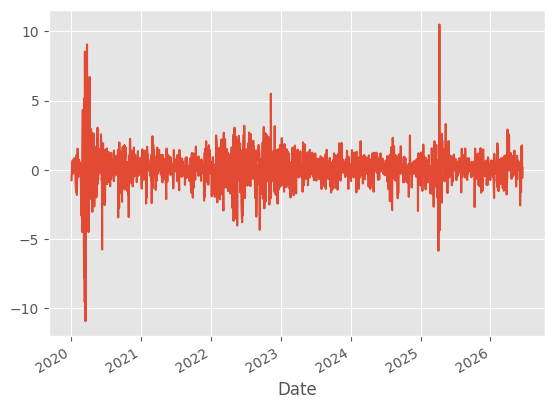

In [30]:
# Graficar los cambios porcentuales diarios para 'SPY'
spy_daily_pc.plot()

In [31]:
# Establecer el primer valor de 'spy_daily_pc' a 0.
# Esto es común ya que el primer día no tiene un dia anterior para poder aplicar formula
# del cambio porcentual.
spy_daily_pc.iloc[0] = 0

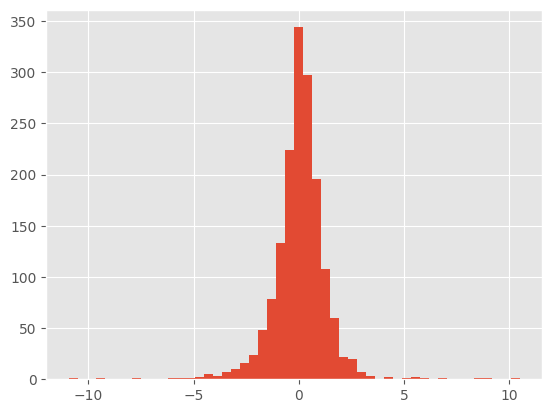

In [32]:
# Crear un histograma de los cambios porcentules diarios de 'SPY' con 50 bins (barras)
plt.hist(spy_daily_pc, bins=50)
# Mostramos el grafico
plt.show()

# El histogrmaa ilustra la distribución de los cambios porcentuales diarios del SPY
# Nos muestra con que frecuencia el precio del SPY sube o baja en un cierto porcentaje.
# Tipicamente estas distribuciones son simetricas alrededor de 0, indicando que 
# pequeños cambios son mas comunes que grandes cambios, y la cola de la distribución
# nos da una pequeña idea de la probabilidad de movimientros extremos en el mercado.

In [33]:
# Calcular el cambio porcentual diario para todas las columans del DF 'stock'
stock_daily_pc = (stock - stock.shift(1)) / stock.shift(1) * 100

In [34]:
# Mostramos las primeras 5 filas
stock_daily_pc.head()

Ticker,SPY,IYW,VT,DBA,TLT,PDBC,IAU
Date,,,,,,,
2020-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-03,-0.757193,-0.998238,-0.904528,-1.151518,1.540035,0.841371,1.368931
2020-01-06,0.381521,0.616900,0.370056,0.245248,-0.567846,0.119172,1.012827
2020-01-07,-0.281192,0.038029,-0.307238,0.244641,-0.491595,-0.178562,0.401072
2020-01-08,0.532969,0.997515,0.406774,-0.488094,-0.661089,-1.371505,-0.732361


In [35]:
# Calcular la suma acumulada de los cambios porcentuales diarios para cada activo
# Esto representa el retorno acumulado a lo largo del tiempo
stock_d_cr = stock_daily_pc.cumsum()

In [36]:
stock_d_cr

Ticker,SPY,IYW,VT,DBA,TLT,PDBC,IAU
Date,,,,,,,
2020-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-03,-0.757193,-0.998238,-0.904528,-1.151518,1.540035,0.841371,1.368931
2020-01-06,-0.375672,-0.381338,-0.534471,-0.906271,0.972190,0.960543,2.381757
2020-01-07,-0.656864,-0.343308,-0.841709,-0.661630,0.480595,0.781981,2.782830
2020-01-08,-0.123895,0.654207,-0.434936,-1.149724,-0.180494,-0.589524,2.050469
...,...,...,...,...,...,...,...
2026-06-11,104.381249,169.650410,89.057738,65.549356,-18.647399,83.875929,110.272616
2026-06-12,104.922074,170.258582,89.494723,65.321221,-18.891649,82.831843,110.348448
2026-06-15,106.685474,174.022302,91.049530,65.854755,-18.949939,81.835360,112.962413


<Axes: xlabel='Date'>

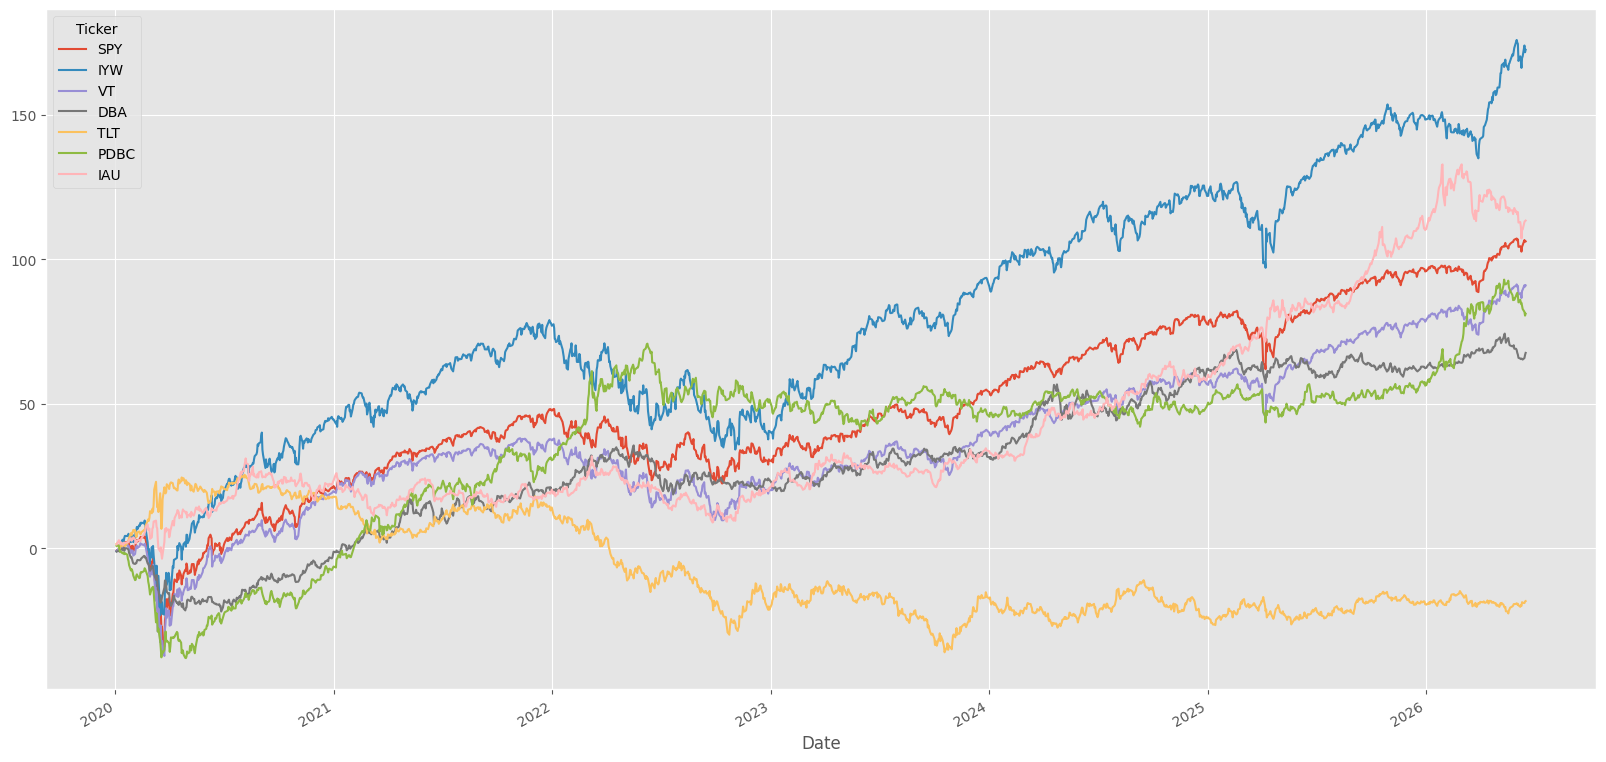

In [37]:
# Graficamos los retornos acumulados de todos los activos.
# 'figsize' definir el tamaño de la figura.
stock_d_cr.plot(figsize=(20,10))


In [38]:
# Calcular la matriz de correlación entre los cambios porcentuales diarios de todos 
# los activos.
# La correlación mide cómo se mueven los precios de los activos entre sí.
df_corr = stock_daily_pc.corr()

In [39]:
# Mostramos la matriz de correlación
df_corr

Ticker,SPY,IYW,VT,DBA,TLT,PDBC,IAU
Ticker,,,,,,,
SPY,1.000000,0.918681,0.974813,0.224915,-0.108924,0.290606,0.148060
IYW,0.918681,1.000000,0.884496,0.187397,-0.063597,0.218686,0.156128
VT,0.974813,0.884496,1.000000,0.245413,-0.094595,0.311775,0.212177
DBA,0.224915,0.187397,0.245413,1.000000,-0.101799,0.461573,0.143306
TLT,-0.108924,-0.063597,-0.094595,-0.101799,1.000000,-0.157642,0.209715
PDBC,0.290606,0.218686,0.311775,0.461573,-0.157642,1.000000,0.291203
IAU,0.148060,0.156128,0.212177,0.143306,0.209715,0.291203,1.000000


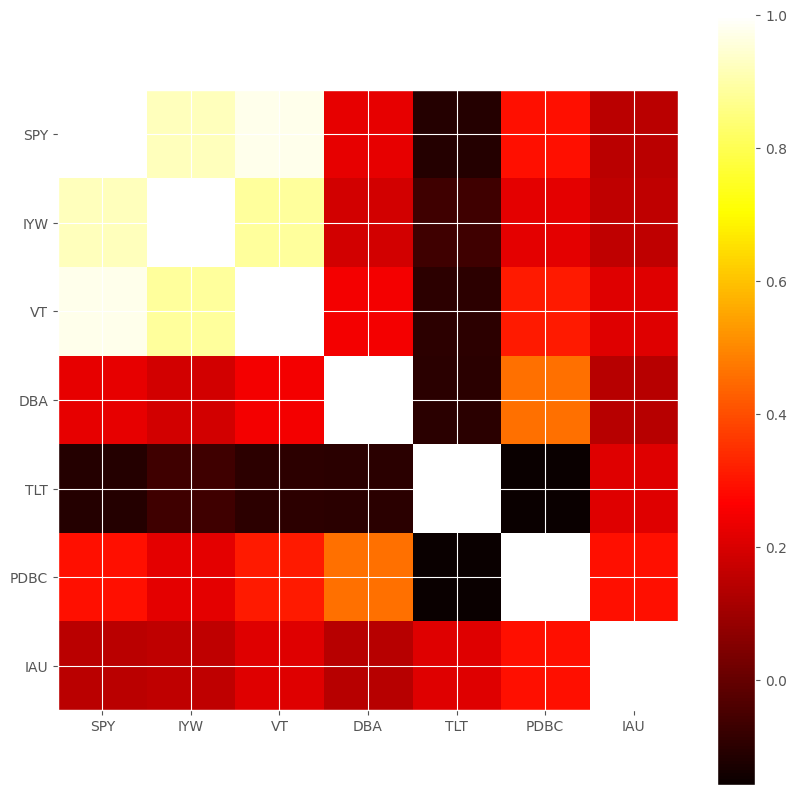

In [40]:
# Vamos a mostrar el gráfico en un 'Mapa de calor'
# Cuanto mas oscuro el color, menor es la correlación
# Cuánto más brillo el color, mayor es la correlación.
# "cmap='hot'" utiliza un mapa de colores cálidos
# 'interpolation = None' evita la interpolación de píxeles.
plt.imshow (df_corr, cmap='hot', interpolation='None')
# Aádimos una barra de color para interpretar los valores
plt.colorbar()
# Establecemos las etiquetas del eje x con los nombres de las columnas del DF de corr
plt.xticks(range(len(df_corr)), df_corr.columns)
# Establecemos las etiquetas del eje y con los nombres de las columnas del DF de corr
plt.yticks(range(len(df_corr)), df_corr.columns)

# Mostramos el el mapa de calor con la altura y la base (10, 10)
plt.gcf().set_size_inches(10,10)

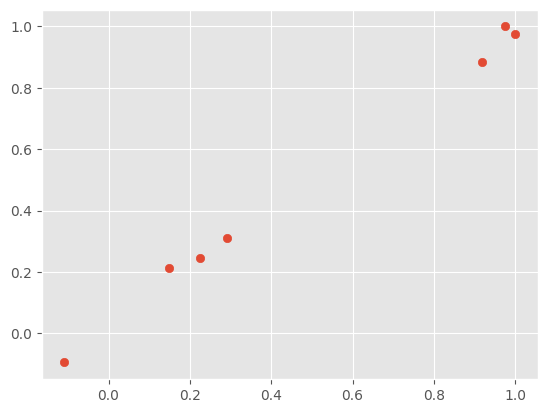

In [41]:
# Creamos un gráfico de dispersión de la correlación de SPY contra VTI
# Esto ayuda a visualizar la relación de como SPY y VT se correlacionan con otros activos
plt.scatter(df_corr['SPY'], df_corr['VT'])
# Mostramos el gráfico
plt.show()

In [42]:
# Definimos el número de periodos para la ventana móvil de 75 días
periods = 75

# Calcular la desviación estándar móvil (volatilidad) de los cambios porcentuales diarios.
# 'rolling(window=periods), ['Hemos asignado el valor de periods a 75], y 'std()' 
# calcula la desviación estándar en esa ventana
vol = stock_daily_pc.rolling(window=periods).std()

# Mostramos el DF 
vol

Ticker,SPY,IYW,VT,DBA,TLT,PDBC,IAU
Date,,,,,,,
2020-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
2026-06-11,0.942180,1.718923,1.138568,0.689580,0.630286,1.530314,1.771706
2026-06-12,0.939604,1.708709,1.136062,0.688499,0.630709,1.537221,1.772125
2026-06-15,0.955810,1.742231,1.147727,0.690369,0.628592,1.543447,1.798522


<Axes: xlabel='Date'>

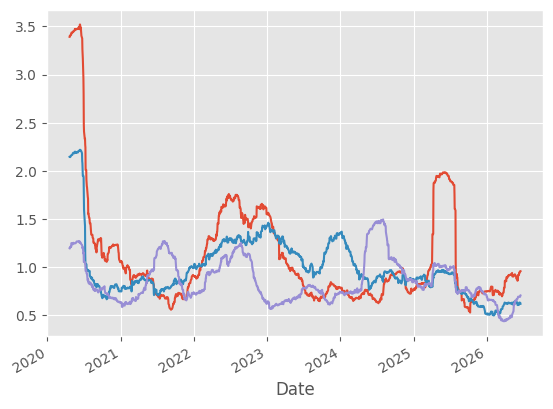

In [44]:
# Graficar la volatilidad de 'SPY'
vol['SPY'].plot()
#Graficar la volatilidad de 'TLT'
vol['TLT'].plot()
# Graficar la volatilidad de 'DBA'
vol['DBA'].plot()

# Esta gráfica muestra la volatilidad a 75 periodos de los cambios porcentuales
# diarios para, SPY, TLT, DBA. La volatilidad es una medida de riesgo, indicando 
# cuánto fluctúa el precio de un activo.
# Los picos en estas línieas sugieren periodos de mayor incertidmbre o movimientos
# de precios más bruscos. Comparar la volatilidad de diferentes activos nos ayuda
# a entender sus perfiles de riesgo relativos a lo largo del tiempo.